In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted!")


Extracted!


In [4]:
data_dir = "/content/dataset"


In [5]:
img_size = (180, 180)
batch_size = 32

data_dir = "/content/dataset/dataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)


Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


In [6]:
import os
print(os.listdir("/content/dataset/dataset"))


['Dog', 'Cat']


In [7]:
print("Cat:", len(os.listdir("/content/dataset/dataset/Cat")))
print("Dog:", len(os.listdir("/content/dataset/dataset/Dog")))


Cat: 12499
Dog: 12499


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


In [10]:
from PIL import Image
import os

root = "/content/dataset/dataset"

fixed = 0

for cls in ["Cat", "Dog"]:
    folder = os.path.join(root, cls)

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        try:
            img = Image.open(path)

            # Convert everything to RGB (3 channels)
            rgb = img.convert("RGB")

            # Overwrite the file
            rgb.save(path)
            fixed += 1

        except Exception as e:
            print("❌ Could not process:", path)
            continue

print("✅ All images converted to RGB")
print("Total files processed:", fixed)


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


✅ All images converted to RGB
Total files processed: 24998


In [11]:
model = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2
)


Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.6876 - loss: 0.5809 - val_accuracy: 0.7558 - val_loss: 0.4949
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.7885 - loss: 0.4461 - val_accuracy: 0.7884 - val_loss: 0.4519


In [13]:
model.save("cats_vs_dogs_model.keras")


In [14]:
# import os
# import PIL
# from PIL import Image

# dataset_path = r"C:/Users/surya/Downloads/dataset"   # change this

# corrupted_files = []

# for root, dirs, files in os.walk(dataset_path):
#     for file in files:
#         file_path = os.path.join(root, file)
#         try:
#             img = Image.open(file_path)
#             img.verify()  # verify image
#         except (PIL.UnidentifiedImageError, OSError, IOError):
#             corrupted_files.append(file_path)

# print("Corrupted files:", corrupted_files)
# print("Total corrupted:", len(corrupted_files))


Saving download.jpg to download.jpg


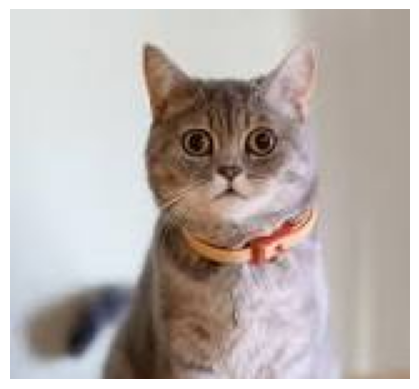

Image shape: (148, 160, 3)


In [15]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Upload image from your device
uploaded = files.upload()   # Opens file chooser

# Get the uploaded file name
file_name = next(iter(uploaded))

# Open the image
img = Image.open(file_name)

# Display the image
plt.imshow(img)
plt.axis('off')
plt.show()

# Convert to array (optional)
img_array = np.array(img)
print("Image shape:", img_array.shape)


In [16]:
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image
import tensorflow as tf
model = load_model("cats_vs_dogs_model.keras")
def predict_image(model, image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((180, 180))

    # Convert to array (NO /255 HERE)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array)[0][0]

    print("Raw Score:", pred)
    print("Prediction:", "DOG 🐶" if pred > 0.5 else "CAT 🐱")
predict_image(model, file_name)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
Raw Score: 0.29008374
Prediction: CAT 🐱
